# Gradient Boosting and Model Optimization

The baseline modeling notebook established three reference models:

- Dummy Regression
- Ridge Regression
- Random Forest Regression

Random Forest achieved the strongest baseline performance, indicating
that nonlinear degradation patterns are important for RUL prediction.

This notebook evaluates gradient boosting as a more sequential and
error-focused ensemble method.

The objectives are to:

- build an untuned gradient-boosting baseline,
- compare it fairly with the previous models,
- evaluate whether additional complexity provides meaningful value,
- and perform only limited optimization when justified by validation
  performance.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GroupShuffleSplit

from xgboost import XGBRegressor

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import EMA_SPAN, ROLLING_WINDOW, RUL_CAP
from src.data_loader import load_cmapss_data
from src.preprocessing import add_sensor_history_features
from src.rul_builder import add_train_rul

## Reproduce the Final Modeling Dataset

To ensure a fair comparison, this notebook recreates the same finalized
dataset and engine-level validation split used in Notebook 04.

The same components are preserved:

- capped RUL target with a maximum of 125 cycles,
- selected sensors,
- 10-cycle rolling window,
- 10-cycle EMA span,
- historical feature definitions,
- random seed,
- validation engines,
- and evaluation metrics.

This ensures that performance differences are caused by the model
rather than by changes in the dataset, target, features, or split.

In [2]:
train_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "train_FD001.txt"
)

df = load_cmapss_data(train_path)

df = add_train_rul(
    df,
    rul_cap=RUL_CAP,
)

In [3]:
selected_sensors = [
    "s2",
    "s3",
    "s4",
    "s7",
    "s11",
    "s12",
    "s15",
    "s17",
    "s20",
    "s21",
]

In [4]:
modeling_df = add_sensor_history_features(
    df,
    sensors=selected_sensors,
    rolling_window=ROLLING_WINDOW,
    ema_span=EMA_SPAN,
).reset_index(drop=True)

In [5]:
rolling_feature_count = modeling_df.filter(
    regex=f"rolling_mean_{ROLLING_WINDOW}$"
).shape[1]

ema_feature_count = modeling_df.filter(
    regex=f"ema_{EMA_SPAN}$"
).shape[1]

assert modeling_df["RUL"].min() == 0
assert modeling_df["RUL"].max() == RUL_CAP
assert (modeling_df["RUL"] <= RUL_CAP).all()

assert rolling_feature_count == len(selected_sensors), (
    "Unexpected number of rolling-mean features."
)

assert ema_feature_count == len(selected_sensors), (
    "Unexpected number of EMA features."
)

print("Final target and temporal configuration validated.")

Final target and temporal configuration validated.


In [6]:
historical_features = [
    f"{sensor}_{suffix}"
    for sensor in selected_sensors
    for suffix in [
        "diff_1",
        f"rolling_mean_{ROLLING_WINDOW}",
        f"ema_{EMA_SPAN}",
        "expanding_mean",
    ]
]

feature_columns = (
    ["cycle"]
    + selected_sensors
    + historical_features
)

target_column = "RUL"
group_column = "id"

In [7]:
group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_indices, validation_indices = next(
    group_splitter.split(
        modeling_df,
        groups=modeling_df[group_column],
    )
)

train_df = (
    modeling_df
    .iloc[train_indices]
    .reset_index(drop=True)
)

validation_df = (
    modeling_df
    .iloc[validation_indices]
    .reset_index(drop=True)
)

X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_validation = validation_df[feature_columns]
y_validation = validation_df[target_column]

In [8]:
print("Training target range:")
print(y_train.min(), y_train.max())

print("\nValidation target range:")
print(y_validation.min(), y_validation.max())

assert y_train.max() == RUL_CAP
assert y_validation.max() == RUL_CAP

print("\nCapped modeling targets validated.")

Training target range:
0 125

Validation target range:
0 125

Capped modeling targets validated.


In [9]:
train_engines = set(train_df["id"].unique())
validation_engines = set(validation_df["id"].unique())

assert train_engines.isdisjoint(validation_engines)
assert len(train_engines) == 80
assert len(validation_engines) == 20
assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0

print("Gradient boosting dataset prepared successfully.")

Gradient boosting dataset prepared successfully.


In [10]:
reference_results = pd.DataFrame(
    [
        {
            "model": "Dummy Mean",
            "MAE": 36.929803,
            "RMSE": 41.720825,
            "R2": -0.000248,
        },
        {
            "model": "Ridge",
            "MAE": 12.817189,
            "RMSE": 16.047358,
            "R2": 0.852018,
        },
        {
            "model": "Random Forest",
            "MAE": 8.415468,
            "RMSE": 11.574838,
            "R2": 0.923010,
        },
    ]
)

reference_results

,model,MAE,RMSE,R2
0,Dummy Mean,36.929803,41.720825,-0.000248
1,Ridge,12.817189,16.047358,0.852018
2,Random Forest,8.415468,11.574838,0.923010


The baseline values below were produced in Notebook 04 using the same:

- capped RUL target,
- 10-cycle historical configuration,
- engine-level validation split,
- selected sensors,
- and evaluation metrics.

They are recorded here as fixed reference results so that the
gradient-boosting models can be compared with the finalized baselines.

Future versions of the project may persist experiment results
automatically rather than entering them manually.

## Histogram Gradient Boosting Baseline

Histogram Gradient Boosting builds trees sequentially.

Each new tree focuses on correcting errors made by the existing
ensemble, unlike Random Forest where trees are trained more
independently and then averaged.

This initial model is intentionally lightly configured. The purpose is
to measure its untuned value before performing any systematic
optimization.

The model is trained using the finalized capped target and 10-cycle
historical feature configuration.

### Early-Stopping Policy

The initial experiment used the estimator's internal early-stopping
mechanism.

However, its internal validation split is not group-aware and may place
cycles from the same engine in both internal training and validation
subsets.

To preserve the engine-level separation policy used throughout the
project, internal early stopping is disabled for this baseline.

Any later optimization will use explicitly separated engine groups
rather than a random row-level validation fraction.

In [11]:
hist_gradient_boosting_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    early_stopping=False,
    random_state=42,
)

In [12]:
hist_gradient_boosting_model.fit(
    X_train,
    y_train,
)

hgb_predictions = hist_gradient_boosting_model.predict(
    X_validation
)

In [13]:
print("Completed boosting iterations:")
print(hist_gradient_boosting_model.n_iter_)

print("\nPrediction range:")
print("Minimum:", hgb_predictions.min())
print("Maximum:", hgb_predictions.max())

assert len(hgb_predictions) == len(y_validation)
assert np.isfinite(hgb_predictions).all()
assert len(np.unique(hgb_predictions)) > 1

Completed boosting iterations:
300

Prediction range:
Minimum: 0.06518215437876317
Maximum: 130.30186407257375


In [14]:
negative_hgb_predictions = (
    hgb_predictions < 0
).sum()

print(
    "Negative gradient boosting predictions:",
    negative_hgb_predictions,
)

Negative gradient boosting predictions: 0


In [15]:
hgb_mae = mean_absolute_error(
    y_validation,
    hgb_predictions,
)

hgb_rmse = root_mean_squared_error(
    y_validation,
    hgb_predictions,
)

hgb_r2 = r2_score(
    y_validation,
    hgb_predictions,
)

print(f"HistGradientBoosting MAE:  {hgb_mae:.3f}")
print(f"HistGradientBoosting RMSE: {hgb_rmse:.3f}")
print(f"HistGradientBoosting R²:   {hgb_r2:.3f}")

HistGradientBoosting MAE:  7.901
HistGradientBoosting RMSE: 11.747
HistGradientBoosting R²:   0.921


In [16]:
hgb_result = pd.DataFrame(
    [
        {
            "model": "HistGradientBoosting",
            "MAE": hgb_mae,
            "RMSE": hgb_rmse,
            "R2": hgb_r2,
        }
    ]
)

model_comparison = pd.concat(
    [
        reference_results,
        hgb_result,
    ],
    ignore_index=True,
).sort_values(
    "MAE"
).reset_index(drop=True)

model_comparison

,model,MAE,RMSE,R2
0,HistGradientBoosting,7.900575,11.747326,0.920699
1,Random Forest,8.415468,11.574838,0.923010
2,Ridge,12.817189,16.047358,0.852018
3,Dummy Mean,36.929803,41.720825,-0.000248


In [17]:
random_forest_mae = 8.415468
random_forest_rmse = 11.574838

hgb_mae_change_vs_rf = (
    (random_forest_mae - hgb_mae)
    / random_forest_mae
    * 100
)

hgb_rmse_change_vs_rf = (
    (random_forest_rmse - hgb_rmse)
    / random_forest_rmse
    * 100
)

print(
    f"MAE improvement over Random Forest: "
    f"{hgb_mae_change_vs_rf:.2f}%"
)

print(
    f"RMSE improvement over Random Forest: "
    f"{hgb_rmse_change_vs_rf:.2f}%"
)

MAE improvement over Random Forest: 6.12%
RMSE improvement over Random Forest: -1.49%


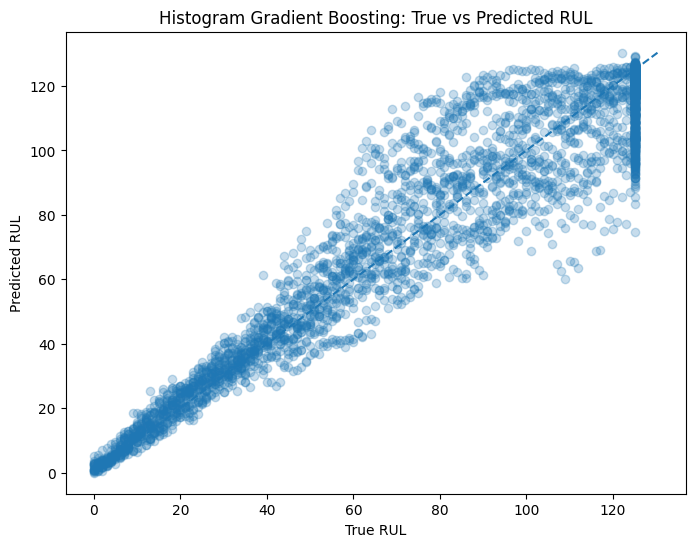

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    hgb_predictions,
    alpha=0.25,
)

minimum_value = min(
    y_validation.min(),
    hgb_predictions.min(),
)

maximum_value = max(
    y_validation.max(),
    hgb_predictions.max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title(
    "Histogram Gradient Boosting: "
    "True vs Predicted RUL"
)
plt.show()

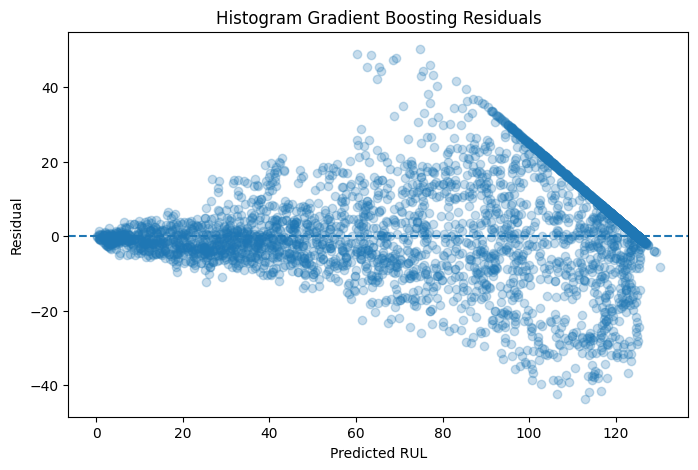

In [19]:
hgb_residuals = (
    y_validation.to_numpy()
    - hgb_predictions
)

plt.figure(figsize=(8, 5))

plt.scatter(
    hgb_predictions,
    hgb_residuals,
    alpha=0.25,
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Predicted RUL")
plt.ylabel("Residual")
plt.title("Histogram Gradient Boosting Residuals")
plt.show()

## XGBoost Baseline

XGBoost is an optimized gradient-boosted tree algorithm widely used for
tabular regression problems.

Unlike Random Forest, where trees are trained more independently and
their predictions are averaged, XGBoost builds trees sequentially.

Each new tree focuses on correcting the residual errors of the existing
ensemble.

This experiment uses the same:

- modeling features,
- engine-level training and validation split,
- target definition,
- and evaluation metrics

as the previous models.

The objective is to evaluate one standard XGBoost configuration, not to
perform extensive hyperparameter optimization.

The experiment uses the finalized capped RUL target and the empirically
selected 10-cycle historical feature configuration.

In [20]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

In [21]:
xgb_model.fit(
    X_train,
    y_train,
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [22]:
xgb_predictions = xgb_model.predict(
    X_validation
)

In [23]:
print("First XGBoost predictions:")
print(xgb_predictions[:5])

print("\nPrediction range:")
print("Minimum:", xgb_predictions.min())
print("Maximum:", xgb_predictions.max())

First XGBoost predictions:
[122.33321 124.66448 123.30842 122.80378 124.59007]

Prediction range:
Minimum: 0.21200682
Maximum: 129.3077


In [24]:
assert len(xgb_predictions) == len(y_validation)

assert np.isfinite(xgb_predictions).all(), (
    "XGBoost predictions must not contain NaN or infinite values."
)

assert len(np.unique(xgb_predictions)) > 1, (
    "XGBoost should not produce constant predictions."
)

In [25]:
negative_xgb_predictions = (
    xgb_predictions < 0
).sum()

negative_xgb_percentage = (
    negative_xgb_predictions
    / len(xgb_predictions)
    * 100
)

print(
    "Negative XGBoost predictions:",
    negative_xgb_predictions,
)

print(
    f"Negative prediction percentage: "
    f"{negative_xgb_percentage:.2f}%"
)

Negative XGBoost predictions: 0
Negative prediction percentage: 0.00%


In [26]:
xgb_mae = mean_absolute_error(
    y_validation,
    xgb_predictions,
)

xgb_rmse = root_mean_squared_error(
    y_validation,
    xgb_predictions,
)

xgb_r2 = r2_score(
    y_validation,
    xgb_predictions,
)

print(f"XGBoost MAE:  {xgb_mae:.3f}")
print(f"XGBoost RMSE: {xgb_rmse:.3f}")
print(f"XGBoost R²:   {xgb_r2:.3f}")

XGBoost MAE:  7.991
XGBoost RMSE: 11.583
XGBoost R²:   0.923


In [27]:
random_forest_mae = 8.415468
random_forest_rmse = 11.574838

xgb_mae_improvement_vs_rf = (
    (random_forest_mae - xgb_mae)
    / random_forest_mae
    * 100
)

xgb_rmse_improvement_vs_rf = (
    (random_forest_rmse - xgb_rmse)
    / random_forest_rmse
    * 100
)

print(
    f"MAE improvement over Random Forest: "
    f"{xgb_mae_improvement_vs_rf:.2f}%"
)

print(
    f"RMSE improvement over Random Forest: "
    f"{xgb_rmse_improvement_vs_rf:.2f}%"
)

MAE improvement over Random Forest: 5.05%
RMSE improvement over Random Forest: -0.07%


In [28]:
xgb_result = pd.DataFrame(
    [
        {
            "model": "XGBoost",
            "MAE": xgb_mae,
            "RMSE": xgb_rmse,
            "R2": xgb_r2,
        }
    ]
)

model_comparison = pd.concat(
    [
        model_comparison,
        xgb_result,
    ],
    ignore_index=True,
)

model_comparison = (
    model_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
)

model_comparison

,model,MAE,RMSE,R2
0,HistGradientBoosting,7.900575,11.747326,0.920699
1,XGBoost,7.990734,11.583455,0.922896
2,Random Forest,8.415468,11.574838,0.923010
3,Ridge,12.817189,16.047358,0.852018
4,Dummy Mean,36.929803,41.720825,-0.000248


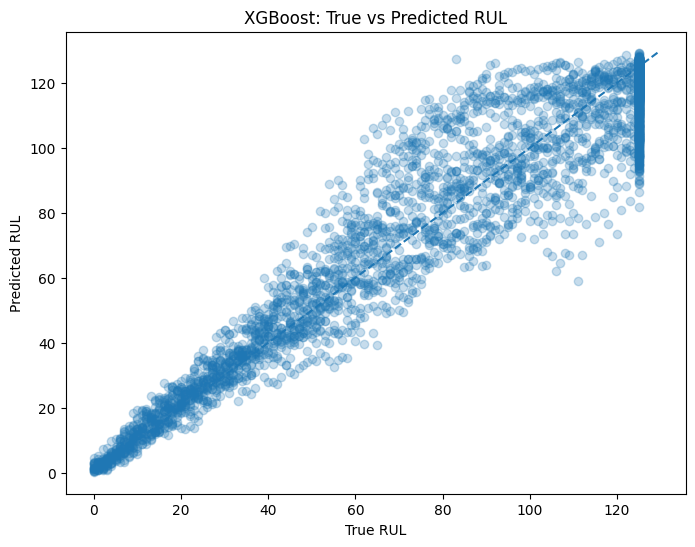

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    xgb_predictions,
    alpha=0.25,
)

minimum_value = min(
    y_validation.min(),
    xgb_predictions.min(),
)

maximum_value = max(
    y_validation.max(),
    xgb_predictions.max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost: True vs Predicted RUL")
plt.show()

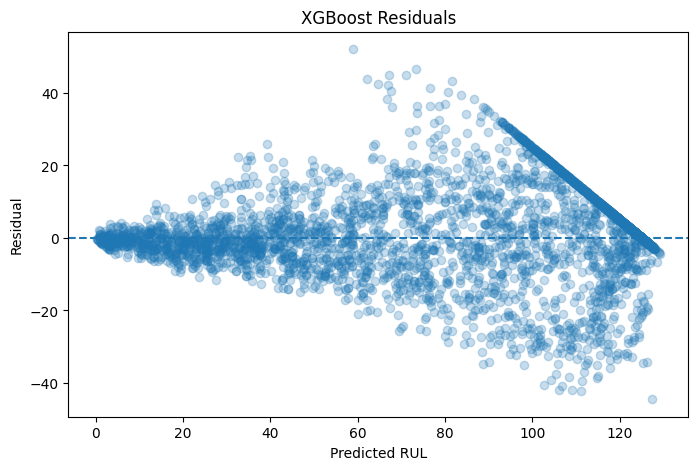

In [30]:
xgb_residuals = (
    y_validation.to_numpy()
    - xgb_predictions
)

plt.figure(figsize=(8, 5))

plt.scatter(
    xgb_predictions,
    xgb_residuals,
    alpha=0.25,
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Predicted RUL")
plt.ylabel("Residual")
plt.title("XGBoost Residuals")
plt.show()

In [31]:
xgb_feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_columns,
).sort_values(
    ascending=False
)

xgb_feature_importance.head(20)

s4_ema_10              0.320588
s4_rolling_mean_10     0.148705
s15_rolling_mean_10    0.072067
s11_ema_10             0.069528
s11_rolling_mean_10    0.057340
s2_rolling_mean_10     0.038857
s21_rolling_mean_10    0.037505
s21_ema_10             0.026684
s3_ema_10              0.025698
cycle                  0.019276
s12_expanding_mean     0.018926
s17_ema_10             0.018878
s3_rolling_mean_10     0.018610
s15_ema_10             0.018580
s17_rolling_mean_10    0.016137
s2_ema_10              0.014608
s11_expanding_mean     0.009160
s20_expanding_mean     0.007460
s7_expanding_mean      0.006622
s17_expanding_mean     0.006403
dtype: float32

### XGBoost Feature Importance Note

XGBoost feature importance indicates how strongly features contributed
to tree construction within this fitted model.

These values are useful for exploratory comparison, but they are not
causal explanations.

Correlated raw, rolling, EMA, and expanding features may divide
importance across several related variables.

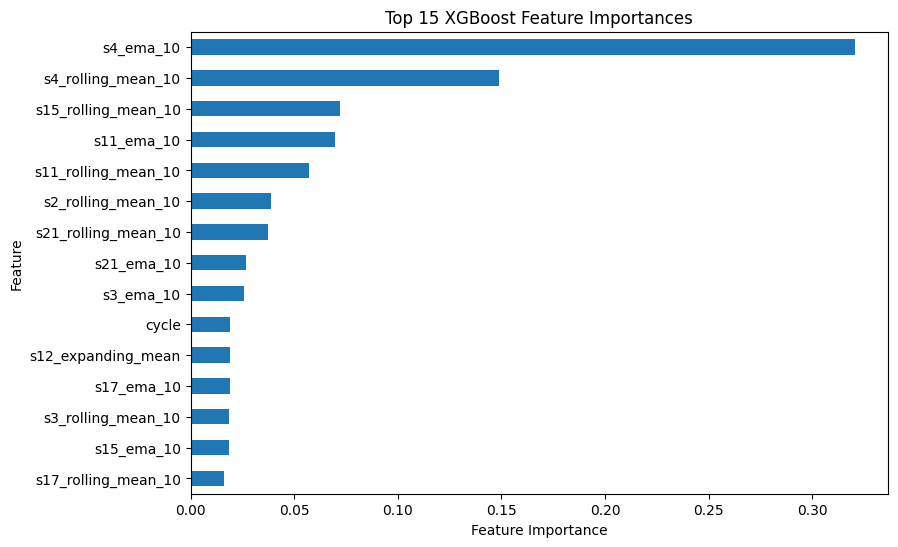

In [32]:
top_xgb_features = (
    xgb_feature_importance
    .head(15)
    .sort_values()
)

plt.figure(figsize=(9, 6))

top_xgb_features.plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.show()

In [33]:
hgb_clipped_predictions = np.clip(
    hgb_predictions,
    0,
    RUL_CAP,
)

xgb_clipped_predictions = np.clip(
    xgb_predictions,
    0,
    RUL_CAP,
)

In [34]:
hgb_above_cap = int(
    (hgb_predictions > RUL_CAP).sum()
)

xgb_above_cap = int(
    (xgb_predictions > RUL_CAP).sum()
)

print("HGB predictions above cap:", hgb_above_cap)
print("XGBoost predictions above cap:", xgb_above_cap)

HGB predictions above cap: 293
XGBoost predictions above cap: 337


In [35]:
hgb_clipped_mae = mean_absolute_error(
    y_validation,
    hgb_clipped_predictions,
)

hgb_clipped_rmse = root_mean_squared_error(
    y_validation,
    hgb_clipped_predictions,
)

hgb_clipped_r2 = r2_score(
    y_validation,
    hgb_clipped_predictions,
)

print(f"Clipped HGB MAE:  {hgb_clipped_mae:.3f}")
print(f"Clipped HGB RMSE: {hgb_clipped_rmse:.3f}")
print(f"Clipped HGB R²:   {hgb_clipped_r2:.3f}")

Clipped HGB MAE:  7.854
Clipped HGB RMSE: 11.744
Clipped HGB R²:   0.921


In [36]:
xgb_clipped_mae = mean_absolute_error(
    y_validation,
    xgb_clipped_predictions,
)

xgb_clipped_rmse = root_mean_squared_error(
    y_validation,
    xgb_clipped_predictions,
)

xgb_clipped_r2 = r2_score(
    y_validation,
    xgb_clipped_predictions,
)

print(f"Clipped XGBoost MAE:  {xgb_clipped_mae:.3f}")
print(f"Clipped XGBoost RMSE: {xgb_clipped_rmse:.3f}")
print(f"Clipped XGBoost R²:   {xgb_clipped_r2:.3f}")

Clipped XGBoost MAE:  7.913
Clipped XGBoost RMSE: 11.571
Clipped XGBoost R²:   0.923


In [37]:
prediction_constraint_results = pd.DataFrame(
    [
        {
            "model": "HistGradientBoosting — raw",
            "MAE": hgb_mae,
            "RMSE": hgb_rmse,
            "R2": hgb_r2,
        },
        {
            "model": "HistGradientBoosting — clipped",
            "MAE": hgb_clipped_mae,
            "RMSE": hgb_clipped_rmse,
            "R2": hgb_clipped_r2,
        },
        {
            "model": "XGBoost — raw",
            "MAE": xgb_mae,
            "RMSE": xgb_rmse,
            "R2": xgb_r2,
        },
        {
            "model": "XGBoost — clipped",
            "MAE": xgb_clipped_mae,
            "RMSE": xgb_clipped_rmse,
            "R2": xgb_clipped_r2,
        },
    ]
)

prediction_constraint_results

,model,MAE,RMSE,R2
0,HistGradientBoosting — raw,7.900575,11.747326,0.920699
1,HistGradientBoosting — clipped,7.853587,11.743507,0.920750
2,XGBoost — raw,7.990734,11.583455,0.922896
3,XGBoost — clipped,7.912739,11.570854,0.923063


## Prediction-Range Constraint

The finalized target is bounded between 0 and 125 cycles.

Although the boosting models produced no negative predictions, some
predictions exceeded the configured RUL cap.

Raw predictions are retained and reported to preserve transparency.
A second evaluation applies an explicit post-processing constraint:

$$
\hat{RUL}_{constrained}
=
\min\left(
125,
\max(0, \hat{RUL})
\right)
$$

This is not hidden model tuning. It enforces the same physical and
statistical range used to define the supervised-learning target.

Both raw and constrained results are reported so that the impact of
post-processing remains visible.

# Notebook Summary

This notebook evaluated two gradient-boosting algorithms under the
finalized project configuration established throughout the previous
notebooks.

The complete experimental pipeline remained fixed during every model
comparison:

- capped Remaining Useful Life (RUL) target with a maximum value of 125 cycles,
- 10-cycle rolling mean,
- 10-cycle exponential moving average (EMA),
- leakage-safe historical feature engineering,
- identical selected sensor set,
- identical engine-level train-validation split,
- identical evaluation metrics.

The final validation results are summarized below.

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| HistGradientBoosting (constrained) | **7.854** | 11.744 | 0.921 |
| XGBoost (constrained) | 7.913 | **11.571** | **0.923** |
| Random Forest | 8.415 | 11.575 | 0.923 |
| Ridge Regression | 12.817 | 16.047 | 0.852 |
| Dummy Mean | 36.930 | 41.721 | -0.000 |

Histogram Gradient Boosting achieved the lowest Mean Absolute Error
(MAE), indicating the smallest average prediction error.

XGBoost achieved the numerically lowest RMSE, although the difference
from Random Forest was negligible.

Because the prediction target is explicitly limited to the interval
[0, 125], an additional constrained evaluation was performed by
clipping predictions outside the valid target range.

Only a small number of predictions exceeded the upper target limit,
and applying the constraint produced modest improvements while keeping
the evaluation fully transparent.

Overall, the three ensemble models demonstrated very similar predictive
performance.

This suggests that the final target engineering strategy and the
historical feature-engineering pipeline contributed more to predictive
accuracy than the choice of ensemble algorithm itself.

The next stage of the project is evaluation on the official NASA
C-MAPSS FD001 test set using the provided test trajectories and
ground-truth RUL labels.

In [38]:
final_results = pd.DataFrame(
    [
        {
            "model": "HistGradientBoosting — constrained",
            "MAE": hgb_clipped_mae,
            "RMSE": hgb_clipped_rmse,
            "R2": hgb_clipped_r2,
        },
        {
            "model": "XGBoost — constrained",
            "MAE": xgb_clipped_mae,
            "RMSE": xgb_clipped_rmse,
            "R2": xgb_clipped_r2,
        },
        {
            "model": "Random Forest",
            "MAE": 8.415468,
            "RMSE": 11.574838,
            "R2": 0.923010,
        },
        {
            "model": "Ridge",
            "MAE": 12.817189,
            "RMSE": 16.047358,
            "R2": 0.852018,
        },
        {
            "model": "Dummy Mean",
            "MAE": 36.929803,
            "RMSE": 41.720825,
            "R2": -0.000248,
        },
    ]
)

final_results["MAE_rank"] = (
    final_results["MAE"]
    .rank(method="dense")
    .astype(int)
)

final_results = (
    final_results
    .sort_values(
        ["MAE_rank", "RMSE"]
    )
    .reset_index(drop=True)
)

final_results

,model,MAE,RMSE,R2,MAE_rank
0,HistGradientBoosting — constrained,7.853587,11.743507,0.920750,1
1,XGBoost — constrained,7.912739,11.570854,0.923063,2
2,Random Forest,8.415468,11.574838,0.923010,3
3,Ridge,12.817189,16.047358,0.852018,4
4,Dummy Mean,36.929803,41.720825,-0.000248,5
